# Soccerfit: A Recommendation System that gets YOU into Soccer by recommending the right players and teams for you!

### Kaggle Dataset: https://www.kaggle.com/datasets/pabloramoswilkins/ucl-2025-players-data

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import sklearn
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('attacking_data.csv')
df_attemps = pd.read_csv('attempts_data.csv')
df_defend = pd.read_csv('defending_data.csv')
df_discipline = pd.read_csv('disciplinary_data.csv')
df_dist = pd.read_csv('distribution_data.csv')
df_goalk = pd.read_csv('goalkeeping_data.csv')
df_goals = pd.read_csv('goals_data.csv')
df_stats = pd.read_csv('key_stats_data.csv')
df_players = pd.read_csv('players_data.csv')
df_teams = pd.read_csv('teams_data.csv')

In [4]:
df_players.head()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,id_team,player_image
0,250016833,Harry Kane,England,Forward,STRIKER,65.0,188.0,31,50037,https://img.uefa.com/imgml/TP/players/1/2025/3...
1,250105927,Viktor Gyökeres,Sweden,Forward,NaN,NaN,NaN,26,50149,https://img.uefa.com/imgml/TP/players/1/2025/3...
2,250121533,Vinícius Júnior,Brazil,Forward,UNKNOWN,NaN,NaN,24,50051,https://img.uefa.com/imgml/TP/players/1/2025/3...
3,250121294,Tijjani Reijnders,Netherlands,Midfielder,CENTRAL_MIDFIELDER,NaN,NaN,26,50058,https://img.uefa.com/imgml/TP/players/1/2025/3...
4,250160436,Maghnes Akliouche,France,Midfielder,UNKNOWN,NaN,NaN,22,50023,https://img.uefa.com/imgml/TP/players/1/2025/3...


In [5]:
df_teams.head()

,team_id,country,team,logo
0,50138,Italy,FC Internazionale Milano,https://img.uefa.com/imgml/TP/teams/logos/70x7...
1,50124,Spain,Atlético de Madrid,https://img.uefa.com/imgml/TP/teams/logos/70x7...
2,50111,Austria,SK Sturm Graz,https://img.uefa.com/imgml/TP/teams/logos/70x7...
3,52816,Italy,Atalanta BC,https://img.uefa.com/imgml/TP/teams/logos/70x7...
4,50050,Scotland,Celtic FC,https://img.uefa.com/imgml/TP/teams/logos/70x7...


In [6]:
df_players.rename(columns={'id_team':'team_id'}, inplace=True)

In [7]:
df_players

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,player_image
0,250016833,Harry Kane,England,Forward,STRIKER,65.0,188.0,31,50037,https://img.uefa.com/imgml/TP/players/1/2025/3...
1,250105927,Viktor Gyökeres,Sweden,Forward,NaN,NaN,NaN,26,50149,https://img.uefa.com/imgml/TP/players/1/2025/3...
2,250121533,Vinícius Júnior,Brazil,Forward,UNKNOWN,NaN,NaN,24,50051,https://img.uefa.com/imgml/TP/players/1/2025/3...
3,250121294,Tijjani Reijnders,Netherlands,Midfielder,CENTRAL_MIDFIELDER,NaN,NaN,26,50058,https://img.uefa.com/imgml/TP/players/1/2025/3...
4,250160436,Maghnes Akliouche,France,Midfielder,UNKNOWN,NaN,NaN,22,50023,https://img.uefa.com/imgml/TP/players/1/2025/3...
...,...,...,...,...,...,...,...,...,...,...
903,250011071,Scott Bain,Scotland,Goalkeeper,GOALKEEPER,NaN,NaN,32,50050,https://img.uefa.com/imgml/TP/players/1/2025/3...
904,250000104,Carlo Pinsoglio,Italy,Goalkeeper,UNKNOWN,NaN,NaN,34,50139,https://img.uefa.com/imgml/TP/players/1/2025/3...
905,108501,Wojciech Szczęsny,Poland,Goalkeeper,GOALKEEPER,84.0,196.0,34,50080,https://img.uefa.com/imgml/TP/players/1/2025/3...
906,103827,César Azpilicueta,Spain,Defender,FULL_BACK,75.0,178.0,35,50124,https://img.uefa.com/imgml/TP/players/1/2025/3...


In [8]:
data = pd.merge(df_players, df_teams, on='team_id', how='left')

In [9]:
data.head()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,player_image,country,team,logo
0,250016833,Harry Kane,England,Forward,STRIKER,65.0,188.0,31,50037,https://img.uefa.com/imgml/TP/players/1/2025/3...,Germany,FC Bayern München,https://img.uefa.com/imgml/TP/teams/logos/70x7...
1,250105927,Viktor Gyökeres,Sweden,Forward,NaN,NaN,NaN,26,50149,https://img.uefa.com/imgml/TP/players/1/2025/3...,Portugal,Sporting Clube de Portugal,https://img.uefa.com/imgml/TP/teams/logos/70x7...
2,250121533,Vinícius Júnior,Brazil,Forward,UNKNOWN,NaN,NaN,24,50051,https://img.uefa.com/imgml/TP/players/1/2025/3...,Spain,Real Madrid C.F.,https://img.uefa.com/imgml/TP/teams/logos/70x7...
3,250121294,Tijjani Reijnders,Netherlands,Midfielder,CENTRAL_MIDFIELDER,NaN,NaN,26,50058,https://img.uefa.com/imgml/TP/players/1/2025/3...,Italy,AC Milan,https://img.uefa.com/imgml/TP/teams/logos/70x7...
4,250160436,Maghnes Akliouche,France,Midfielder,UNKNOWN,NaN,NaN,22,50023,https://img.uefa.com/imgml/TP/players/1/2025/3...,France,AS Monaco,https://img.uefa.com/imgml/TP/teams/logos/70x7...


In [10]:
data = data.drop(columns=['player_image', 'logo'])

In [11]:
data.head()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team
0,250016833,Harry Kane,England,Forward,STRIKER,65.0,188.0,31,50037,Germany,FC Bayern München
1,250105927,Viktor Gyökeres,Sweden,Forward,NaN,NaN,NaN,26,50149,Portugal,Sporting Clube de Portugal
2,250121533,Vinícius Júnior,Brazil,Forward,UNKNOWN,NaN,NaN,24,50051,Spain,Real Madrid C.F.
3,250121294,Tijjani Reijnders,Netherlands,Midfielder,CENTRAL_MIDFIELDER,NaN,NaN,26,50058,Italy,AC Milan
4,250160436,Maghnes Akliouche,France,Midfielder,UNKNOWN,NaN,NaN,22,50023,France,AS Monaco


In [12]:
df.head()

,id_player,assists,corners_taken,offsides,dribbles
0,250052469,4.0,0.0,1.0,9.0
1,250130414,3.0,21.0,0.0,2.0
2,250070417,3.0,19.0,0.0,0.0
3,250112880,3.0,12.0,2.0,7.0
4,250177886,3.0,8.0,0.0,5.0


In [13]:
df_attemps.head()

,id_player,total_attempts,attempts_on_target,attempts_off_target,blocked
0,250016833,20.0,12.0,6.0,2.0
1,250103758,21.0,10.0,5.0,6.0
2,250121533,17.0,10.0,6.0,1.0
3,250076574,20.0,9.0,5.0,6.0
4,250105927,15.0,8.0,3.0,4.0


In [14]:
df_defend.head()

,id_player,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted
0,250174126,41.0,4.0,1.0,3.0,10.0
1,250188247,33.0,4.0,1.0,3.0,10.0
2,250139010,32.0,3.0,0.0,3.0,10.0
3,250132323,31.0,5.0,1.0,4.0,11.0
4,250188511,31.0,4.0,4.0,0.0,12.0


In [15]:
df_discipline.head()

,Unnamed: 0,id_player,fouls_committed,fouls_suffered,yellow_cards,red_cards
0,0,250112690,11.0,7.0,1,0
1,1,250065419,11.0,4.0,2,0
2,2,250105927,10.0,7.0,0,0
3,3,250129965,10.0,5.0,1,0
4,4,250025791,9.0,7.0,2,0


In [16]:
df_discipline.drop(columns=['Unnamed: 0'], inplace=True)

In [17]:
df_dist.sample(10)

,id_player,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance
152,250123978,91.50,51.0,45.0,0.0,0.0,0.0,1.0,2.0
239,250064444,89.00,261.0,233.0,0.0,1.0,0.0,10.0,4.0
119,250124169,92.34,89.0,81.0,50.0,4.0,2.0,0.0,3.0
149,250135672,91.50,188.0,173.0,0.0,0.0,0.0,5.0,4.0
882,250082738,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
95,250153701,93.34,19.0,17.0,0.0,0.0,0.0,0.0,3.0
545,250177497,77.00,72.0,51.0,0.0,1.0,0.0,3.0,4.0
724,250104128,0.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0
456,250020850,81.67,37.0,31.0,0.0,0.0,0.0,1.0,3.0
168,250113392,91.00,78.0,69.0,0.0,0.0,0.0,0.0,3.0


In [18]:
df_goalk.sample()

,id_player,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made
733,250200248,NaN,NaN,NaN,NaN,NaN


In [19]:
df_goals.head()

,id_player,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored
0,250112880,5.0,3.0,2.0,1.0,4.0,0.0,0.0,0.0
1,250139445,3.0,1.0,2.0,2.0,1.0,0.0,0.0,0.0
2,250121533,4.0,3.0,1.0,2.0,2.0,0.0,0.0,1.0
3,250159544,3.0,2.0,1.0,3.0,0.0,0.0,0.0,0.0
4,250091187,3.0,2.0,1.0,2.0,1.0,0.0,0.0,0.0


In [20]:
df_stats.head()

,id_player,distance_covered(km/h),top_speed,minutes_played,matches_appareance
0,250016833,43.71,30.35,360.0,4.0
1,250105927,41.94,34.55,360.0,4.0
2,250121533,38.39,35.47,360.0,4.0
3,250121294,46.61,32.26,360.0,4.0
4,250160436,44.67,33.39,360.0,4.0


In [21]:
data = data.merge(df,on='id_player',how='left')
data =data.merge(df_attemps,on='id_player',how='left')
data =data.merge(df_defend,on='id_player',how='left')
data =data.merge(df_discipline,on='id_player',how='left')
data =data.merge(df_dist,on='id_player',how='left')
data =data.merge(df_goalk,on='id_player',how='left')
data =data.merge(df_goals,on='id_player',how='left')
data =data.merge(df_stats,on='id_player',how='left')

In [22]:
data.notna().sum()

id_player                 908
player_name               908
nationality               908
field_position            908
position                  701
weight(kg)                154
height(cm)                179
age                       908
team_id                   908
country                   908
team                      908
assists                   727
corners_taken             727
offsides                  727
dribbles                  727
total_attempts            727
attempts_on_target        727
attempts_off_target       727
blocked                   727
balls_recovered           727
tackles                   727
tackles_won               727
tackles_lost              727
clearance_attempted       727
fouls_committed           727
fouls_suffered            727
yellow_cards              908
red_cards                 908
passing_accuracy(%)       727
passes_attempted          727
passes_completed          727
crossing_accuracy(%)      908
crosses_attempted         727
crosses_co

In [23]:
data.shape

(908, 53)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 53 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_player               908 non-null    int64  
 1   player_name             908 non-null    object 
 2   nationality             908 non-null    object 
 3   field_position          908 non-null    object 
 4   position                701 non-null    object 
 5   weight(kg)              154 non-null    float64
 6   height(cm)              179 non-null    float64
 7   age                     908 non-null    int64  
 8   team_id                 908 non-null    int64  
 9   country                 908 non-null    object 
 10  team                    908 non-null    object 
 11  assists                 727 non-null    float64
 12  corners_taken           727 non-null    float64
 13  offsides                727 non-null    float64
 14  dribbles                727 non-null    fl

## Data Cleaning

In [25]:
#We will use this data later.
team_data = data.groupby('team').mean(numeric_only=True)

In [26]:
data.sample(5)

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,matches_appareance
793,250176229,Max Schmitt,Germany,Goalkeeper,UNKNOWN,NaN,NaN,18,50037,Germany,FC Bayern München,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
416,250067295,João Palhinha,Portugal,Midfielder,DEFENSIVE_MIDFIELDER,NaN,189.0,29,50037,Germany,FC Bayern München,0.0,0.0,0.0,0.0,4.0,0.0,2.0,2.0,7.0,12.0,5.0,7.0,0.0,1.0,0.0,0,0,93.67,133.0,126.0,0.00,0.0,0.0,2.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.37,30.13,165.0,3.0
544,250174737,Alexander Meyer,Germany,Goalkeeper,UNKNOWN,NaN,NaN,33,52758,Germany,Borussia Dortmund,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,85.00,48.0,41.0,0.00,0.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.82,21.91,90.0,1.0
11,250106969,Miguel Gutiérrez,Spain,Defender,UNKNOWN,NaN,NaN,23,2602798,Spain,Girona FC,0.0,3.0,0.0,10.0,6.0,2.0,1.0,3.0,12.0,4.0,2.0,2.0,2.0,2.0,6.0,0,0,85.75,178.0,152.0,26.67,15.0,4.0,7.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,43.79,31.57,360.0,4.0
341,250113237,Nicolò Fagioli,Italy,Midfielder,UNKNOWN,NaN,NaN,23,50139,Italy,Juventus,0.0,1.0,0.0,11.0,5.0,1.0,3.0,1.0,8.0,4.0,3.0,1.0,3.0,1.0,0.0,0,0,86.67,122.0,109.0,0.00,5.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.60,30.72,201.0,3.0


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 53 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_player               908 non-null    int64  
 1   player_name             908 non-null    object 
 2   nationality             908 non-null    object 
 3   field_position          908 non-null    object 
 4   position                701 non-null    object 
 5   weight(kg)              154 non-null    float64
 6   height(cm)              179 non-null    float64
 7   age                     908 non-null    int64  
 8   team_id                 908 non-null    int64  
 9   country                 908 non-null    object 
 10  team                    908 non-null    object 
 11  assists                 727 non-null    float64
 12  corners_taken           727 non-null    float64
 13  offsides                727 non-null    float64
 14  dribbles                727 non-null    fl

In [28]:
data.drop_duplicates(inplace=True)

In [29]:
data.shape

(908, 53)

In [30]:
data['weight(kg)'].isna().sum()

np.int64(754)

In [31]:
#Average out weight
team_mean = data.groupby('team')['weight(kg)'].transform('mean')
nat_mean = data.groupby('nationality')['weight(kg)'].transform('mean')
pos_mean = data.groupby('field_position')['weight(kg)'].transform('mean')
data['height_bin'] = pd.cut(data['height(cm)'], bins=5)
height_mean = data.groupby('height_bin', observed=True)['weight(kg)'].transform('mean')
combined = (
    0.25 * team_mean +
    0.25 * nat_mean +
    0.25 * pos_mean +
    0.25 * height_mean
)

data['weight(kg)'] = data['weight(kg)'].fillna(combined)
data['weight(kg)'] = data['weight(kg)'].fillna(data['weight(kg)'].mean())
data['weight(kg)'] += np.random.normal(0, 1.5, size=len(data))

In [32]:
data['weight(kg)'].nunique()

908

<Axes: >

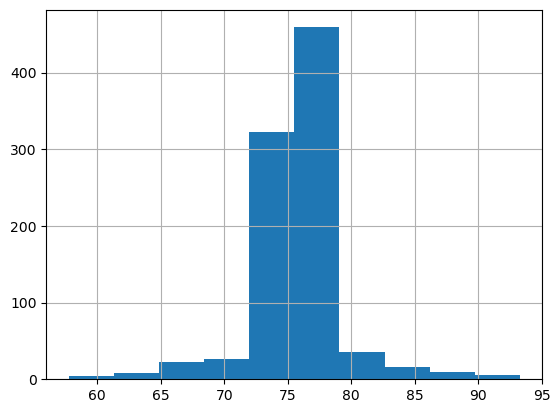

In [33]:
data['weight(kg)'].hist()

In [34]:
data.sample(15)

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,matches_appareance,height_bin
489,250153851,El Chadaille Bitshiabu,France,Defender,NaN,73.567065,NaN,19,2603790,Germany,RB Leipzig,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,8.0,0.0,1.0,0,0,92.00,94.0,85.0,0.00,0.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.30,34.42,106.0,2.0,NaN
677,250187320,Bjorn Meijer,Netherlands,Defender,NaN,78.100543,NaN,21,50043,Belgium,Club Brugge KV,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,67.00,3.0,2.0,0.00,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.48,31.81,15.0,1.0,NaN
105,250169706,Daizen Maeda,Japan,Forward,UNKNOWN,74.252000,NaN,27,50050,Scotland,Celtic FC,0.0,0.0,2.0,6.0,7.0,3.0,4.0,0.0,7.0,6.0,2.0,4.0,3.0,5.0,1.0,0,0,78.75,71.0,58.0,25.00,4.0,1.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,43.92,35.39,344.0,4.0,NaN
178,250171055,Kenan Yıldız,Türkiye,Forward,UNKNOWN,76.082990,NaN,19,50139,Italy,Juventus,0.0,2.0,3.0,13.0,8.0,2.0,2.0,4.0,6.0,1.0,0.0,1.0,0.0,3.0,8.0,0,0,80.25,107.0,86.0,25.00,12.0,3.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,36.82,34.16,300.0,4.0,NaN
155,250112880,Raphinha,Brazil,Forward,WINGER,77.365997,NaN,27,50080,Spain,FC Barcelona,3.0,12.0,2.0,7.0,15.0,5.0,8.0,2.0,3.0,1.0,1.0,0.0,0.0,2.0,4.0,0,0,71.00,135.0,99.0,23.08,13.0,3.0,6.0,4.0,0.0,0.0,0.0,1.0,0.0,5.0,3.0,2.0,1.0,4.0,0.0,0.0,0.0,38.69,33.37,314.0,4.0,NaN
389,250089824,Andriy Lunin,Ukraine,Goalkeeper,GOALKEEPER,75.177806,NaN,25,50051,Spain,Real Madrid C.F.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,95.50,34.0,32.0,0.00,0.0,0.0,0.0,2.0,8.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.07,25.69,180.0,2.0,NaN
796,250176188,Mats Seiler,Switzerland,Defender,NaN,76.541843,NaN,19,50031,Switzerland,BSC Young Boys,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,250061721,Kenan Bajrić,Slovenia,Defender,CENTRE_BACK,75.312600,NaN,29,52797,Slovakia,ŠK Slovan Bratislava,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,16.0,2.0,1.0,1.0,18.0,1.0,4.0,0,0,85.00,144.0,127.0,0.00,0.0,0.0,5.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.24,33.96,360.0,4.0,NaN
18,250134304,Gabriel Martinelli,Brazil,Forward,WINGER,76.398823,NaN,23,52280,England,Arsenal FC,1.0,4.0,0.0,8.0,8.0,3.0,3.0,2.0,4.0,1.0,1.0,0.0,2.0,2.0,1.0,1,0,81.75,99.0,80.0,40.91,22.0,9.0,0.0,4.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.12,34.39,360.0,4.0,NaN
610,250081720,Dani Olmo,Spain,Forward,WINGER,67.138209,176.0,26,50080,Spain,FC Barcelona,0.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,78.00,26.0,20.0,100.00,1.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.17,28.64,47.0,2.0,"(175.8, 181.6]"


In [35]:
#FOR REFERENCE: HIS ACTUAL WEIGHT IS 93 KG. THIS MAKES MY SCALING VERY ACCURATE!!!
data[data['weight(kg)'] == data['weight(kg)'].max()]

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,matches_appareance,height_bin
154,97923,Manuel Neuer,Germany,Goalkeeper,GOALKEEPER,93.270542,193.0,38,50037,Germany,FC Bayern München,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,90.75,156.0,139.0,0.0,0.0,0.0,6.0,4.0,1.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.67,24.91,315.0,4.0,"(187.4, 193.2]"


In [36]:
##all values filled.
data['weight(kg)'].isna().sum()

np.int64(0)

In [37]:
data['field_position'] = data['field_position'].fillna('Unknown')
data['position'] = data['position'].fillna('Unknown')

In [38]:
data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,matches_appareance,height_bin
241,250119677,Ramy Bensebaini,Algeria,Defender,CENTRE_BACK,75.145355,NaN,29,52758,Germany,Borussia Dortmund,0.0,0.0,0.0,5.0,2.0,0.0,1.0,1.0,12.0,12.0,2.0,10.0,9.0,3.0,2.0,1,0,85.75,160.0,140.0,0.0,2.0,0.0,6.0,4.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.69,33.16,268.0,4.0,NaN


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id_player               908 non-null    int64   
 1   player_name             908 non-null    object  
 2   nationality             908 non-null    object  
 3   field_position          908 non-null    object  
 4   position                908 non-null    object  
 5   weight(kg)              908 non-null    float64 
 6   height(cm)              179 non-null    float64 
 7   age                     908 non-null    int64   
 8   team_id                 908 non-null    int64   
 9   country                 908 non-null    object  
 10  team                    908 non-null    object  
 11  assists                 727 non-null    float64 
 12  corners_taken           727 non-null    float64 
 13  offsides                727 non-null    float64 
 14  dribbles                72

In [40]:
cols = [
    'assists', 'dribbles', 'tackles', 'goals',
    'crosses_attempted', 'passes_completed',
    'fouls_committed', 'minutes_played'
]

data[cols] = data[cols].fillna(0)

In [41]:
data['field_position'].unique()

array(['Forward', 'Midfielder', 'Defender', 'Goalkeeper'], dtype=object)

In [42]:
gk_cols = ['saves', 'goals_conceded', 'clean_sheets', 'punches_made']

data[gk_cols] = data[gk_cols].fillna(0)

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id_player               908 non-null    int64   
 1   player_name             908 non-null    object  
 2   nationality             908 non-null    object  
 3   field_position          908 non-null    object  
 4   position                908 non-null    object  
 5   weight(kg)              908 non-null    float64 
 6   height(cm)              179 non-null    float64 
 7   age                     908 non-null    int64   
 8   team_id                 908 non-null    int64   
 9   country                 908 non-null    object  
 10  team                    908 non-null    object  
 11  assists                 908 non-null    float64 
 12  corners_taken           727 non-null    float64 
 13  offsides                727 non-null    float64 
 14  dribbles                90

In [44]:
data = data.drop(columns=['matches_appareance'])

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 53 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id_player               908 non-null    int64   
 1   player_name             908 non-null    object  
 2   nationality             908 non-null    object  
 3   field_position          908 non-null    object  
 4   position                908 non-null    object  
 5   weight(kg)              908 non-null    float64 
 6   height(cm)              179 non-null    float64 
 7   age                     908 non-null    int64   
 8   team_id                 908 non-null    int64   
 9   country                 908 non-null    object  
 10  team                    908 non-null    object  
 11  assists                 908 non-null    float64 
 12  corners_taken           727 non-null    float64 
 13  offsides                727 non-null    float64 
 14  dribbles                90

In [46]:
#Now I will deal with height:
import numpy as np

# Track missing
missing_mask = data['height(cm)'].isna()

# Group means for HEIGHT (not weight)
nat_h = data.groupby('nationality')['height(cm)'].transform('mean')
pos_h = data.groupby('field_position')['height(cm)'].transform('mean')

# Combine (position matters more)
combined_h = (
    0.6 * pos_h +
    0.4 * nat_h
)

# Fill missing
data.loc[missing_mask, 'height(cm)'] = combined_h[missing_mask]

# Fallback
data['height(cm)'] = data['height(cm)'].fillna(data['height(cm)'].mean())

# Add noise ONLY to imputed values
data.loc[missing_mask, 'height(cm)'] += np.random.normal(0, 1.5, size=missing_mask.sum())

In [47]:
#his height is 200 cm
data[data['height(cm)'] == data['height(cm)'].max()]

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,height_bin
391,250011668,Thibaut Courtois,Belgium,Goalkeeper,GOALKEEPER,89.208639,199.0,32,50051,Spain,Real Madrid C.F.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,91.0,66.0,59.0,0.0,0.0,0.0,6.0,2.0,11.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.41,25.7,180.0,"(193.2, 199.0]"


<Axes: >

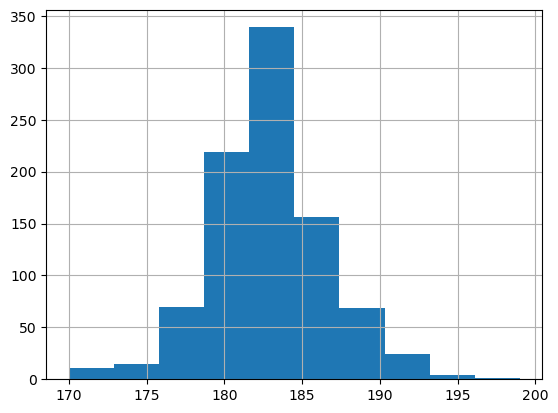

In [48]:
data['height(cm)'].hist()

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 53 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id_player               908 non-null    int64   
 1   player_name             908 non-null    object  
 2   nationality             908 non-null    object  
 3   field_position          908 non-null    object  
 4   position                908 non-null    object  
 5   weight(kg)              908 non-null    float64 
 6   height(cm)              908 non-null    float64 
 7   age                     908 non-null    int64   
 8   team_id                 908 non-null    int64   
 9   country                 908 non-null    object  
 10  team                    908 non-null    object  
 11  assists                 908 non-null    float64 
 12  corners_taken           727 non-null    float64 
 13  offsides                727 non-null    float64 
 14  dribbles                90

In [50]:
data = data.drop(columns='height_bin')

In [51]:
data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played
374,250172787,Jerdy Schouten,Netherlands,Midfielder,UNKNOWN,76.396379,181.508104,27,50062,Netherlands,PSV Eindhoven,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,17.0,2.0,0.0,2.0,2.0,5.0,3.0,0,0,89.5,139.0,124.0,0.0,0.0,0.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,21.69,30.3,180.0


In [52]:
#This indicates that all the NaN values are for the players that have 0 minutes played.
len(data[data['minutes_played']==0])

181

In [53]:
data[data['minutes_played']==0] = data[data['minutes_played']==0].fillna(0)

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 52 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_player               908 non-null    int64  
 1   player_name             908 non-null    object 
 2   nationality             908 non-null    object 
 3   field_position          908 non-null    object 
 4   position                908 non-null    object 
 5   weight(kg)              908 non-null    float64
 6   height(cm)              908 non-null    float64
 7   age                     908 non-null    int64  
 8   team_id                 908 non-null    int64  
 9   country                 908 non-null    object 
 10  team                    908 non-null    object 
 11  assists                 908 non-null    float64
 12  corners_taken           908 non-null    float64
 13  offsides                908 non-null    float64
 14  dribbles                908 non-null    fl

In [55]:
data[data['player_name'] == 'Erling Haaland']

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played
143,250103758,Erling Haaland,Norway,Forward,UNKNOWN,73.714596,177.341684,24,52919,England,Manchester City,0.0,0.0,0.0,1.0,21.0,10.0,5.0,6.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0,0,84.25,22.0,18.0,0.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,3.0,0.0,3.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,33.95,34.86,321.0


##### Data Cleaning Complete!

### Feature Engineering

In [56]:
data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played
872,250105664,Daniel Peretz,Israel,Goalkeeper,GOALKEEPER,76.707924,181.807123,24,50037,Germany,FC Bayern München,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
data['avg_goals_per_game'] = data['goals']/(data['minutes_played']/90)
data['avg_goals_per_game'] = data['avg_goals_per_game'].fillna(0)

In [58]:
data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,avg_goals_per_game
411,250144965,Darwin Núñez,Uruguay,Forward,STRIKER,76.500116,182.443878,25,7889,England,Liverpool FC,0.0,0.0,2.0,2.0,9.0,5.0,2.0,2.0,6.0,0.0,0.0,0.0,0.0,3.0,2.0,0,0,65.75,39.0,25.0,0.0,2.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,22.67,34.31,167.0,0.538922


In [59]:
data['assists_per_90'] = data['assists']/(data['minutes_played']/90)
data['assists_per_90'] = data['assists_per_90'].fillna(0)

In [60]:
data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,avg_goals_per_game,assists_per_90
762,250189610,Viggo Gebel,Germany,Midfielder,UNKNOWN,74.509221,182.67701,16,2603790,Germany,RB Leipzig,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
data['passes_per_90'] = data['passes_completed'] / (data['minutes_played'] / 90)
data['team_index'] = (
    0.4 * data['passing_accuracy(%)'] +
    0.3 * data['passes_per_90'] + 0.1 * data['passes_attempted'] + 0.2 * data['assists_per_90']
)
data['passes_per_90'] = data['passes_per_90'].fillna(0)
data['team_index'] = data['team_index'].fillna(0)

In [62]:
data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,avg_goals_per_game,assists_per_90,passes_per_90,team_index
230,250124068,Castello Lukeba,France,Defender,UNKNOWN,75.950494,180.859432,21,2603790,Germany,RB Leipzig,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,21.0,5.0,1.0,4.0,13.0,3.0,4.0,2,0,91.0,213.0,195.0,0.0,1.0,0.0,7.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.54,35.09,270.0,0.0,0.0,65.0,77.2


In [63]:
data['showman_index'] = (data['head'] + data['dribbles'] + data['red_cards'] + data['yellow_cards']) / (data['minutes_played'] / 90)

In [64]:
data['appearance'] = data['minutes_played'] * 0.5 + data['matches_appearance'] * 0.5

In [65]:
data['distance_covered(km/h)'].max()

50.46

In [66]:
data['aggression_index'] = (
    1.0 * data['tackles_won'] +
    1.5 * data['fouls_committed'] +
    3.0 * data['yellow_cards'] +
    6.0 * data['red_cards']
) / (data['minutes_played'] / 90)

In [67]:
data['runner_index'] = (
    data['distance_covered(km/h)'] +
    data['top_speed']
)

In [68]:
data['saves_per_90']= data['saves'] / (data['minutes_played'] / 90)
data['clean_sheets_per_90'] = data['clean_sheets'] / (data['minutes_played'] / 90)
data['goals_conceded_per_90'] = data['goals_conceded'] / (data['minutes_played'] / 90)
data['punches_made_per_90'] = data['punches_made'] / (data['minutes_played'] / 90)

In [69]:
data = data.fillna(0)

#### Normalizing and deciding final features

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 64 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_player               908 non-null    int64  
 1   player_name             908 non-null    object 
 2   nationality             908 non-null    object 
 3   field_position          908 non-null    object 
 4   position                908 non-null    object 
 5   weight(kg)              908 non-null    float64
 6   height(cm)              908 non-null    float64
 7   age                     908 non-null    int64  
 8   team_id                 908 non-null    int64  
 9   country                 908 non-null    object 
 10  team                    908 non-null    object 
 11  assists                 908 non-null    float64
 12  corners_taken           908 non-null    float64
 13  offsides                908 non-null    float64
 14  dribbles                908 non-null    fl

In [71]:
outfield_features = [
    'height(cm)',
    'weight(kg)',
    'avg_goals_per_game',
    'team_index',
    'showman_index',
    'top_speed','runner_index','aggression_index'
]
gk_features = [
    'saves_per_90',
    'clean_sheets_per_90',
    'goals_conceded_per_90',
    'punches_made_per_90', 'height(cm)','weight(kg)','saves_on_penalty'
]

### Adding Archetypes using K-means Clustering & Using KNN to find the best player

In [72]:
gk_data = data[data['field_position'] == 'Goalkeeper'].copy()
outfield_data = data[data['field_position'] != 'Goalkeeper'].copy()

In [73]:
from sklearn.preprocessing import StandardScaler

scaler_out = StandardScaler()

X_out = scaler_out.fit_transform(outfield_data[outfield_features])

out_scaled_cols = [f"{col}_scaled" for col in outfield_features]
outfield_data[out_scaled_cols] = X_out

In [74]:
scaler_gk = StandardScaler()

X_gk = scaler_gk.fit_transform(gk_data[gk_features])

gk_scaled_cols = [f"{col}_scaled" for col in gk_features]
gk_data[gk_scaled_cols] = X_gk

In [75]:
from sklearn.cluster import KMeans

kmeans_out = KMeans(n_clusters=6, random_state=42)

outfield_data['archetype'] = kmeans_out.fit_predict(outfield_data[out_scaled_cols])

In [76]:
kmeans_gk = KMeans(n_clusters=3, random_state=42)

gk_data['archetype'] = kmeans_gk.fit_predict(gk_data[gk_scaled_cols])

In [77]:
out_summary = outfield_data.groupby('archetype')[outfield_features].mean()
print(out_summary)

           height(cm)  weight(kg)  avg_goals_per_game  team_index  \
archetype                                                           
0          183.139509   75.777110            1.200231   46.819120   
1          182.383705   75.827199            0.000000    0.000000   
2          184.471167   76.751981            0.056655   67.219929   
3          181.687061   75.224456            0.043016   45.337718   
4          175.468085   66.969846            0.076432   57.410742   
5          181.110802   75.611982            0.047179   47.677785   

           showman_index  top_speed  runner_index  aggression_index  
archetype                                                            
0               2.493199  32.517755     56.404898          2.710632  
1               0.000000   0.000000      0.000000          0.000000  
2               0.857268  31.969676     61.864167          2.650345  
3               8.954351  31.106667     42.513030         15.095032  
4               1.458764  3

In [78]:
out_names = {
    0: "Explosive Attacker",
    1: "Creative Playmaker",
    2: "Physical Engine",
    3: "Defensive Enforcer",
    4: "Balanced Player",
    5: "Speedster"
}

outfield_data['archetype_name'] = outfield_data['archetype'].map(out_names)

In [79]:
outfield_data.head()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,avg_goals_per_game,assists_per_90,passes_per_90,team_index,showman_index,appearance,aggression_index,runner_index,saves_per_90,clean_sheets_per_90,goals_conceded_per_90,punches_made_per_90,height(cm)_scaled,weight(kg)_scaled,avg_goals_per_game_scaled,team_index_scaled,showman_index_scaled,top_speed_scaled,runner_index_scaled,aggression_index_scaled,archetype,archetype_name
0,250016833,Harry Kane,England,Forward,STRIKER,63.113589,188.000000,31,50037,Germany,FC Bayern München,1.0,0.0,3.0,10.0,20.0,12.0,6.0,2.0,3.0,2.0,1.0,1.0,1.0,2.0,6.0,0,0,82.00,118.0,97.0,0.00,1.0,0.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0,5.0,5.0,0.0,5.0,0.0,0.0,0.0,3.0,43.71,30.35,360.0,1.25,0.25,24.25,51.925,2.50,182.0,1.000,74.06,0.0,0.25,0.0,0.0,1.828153,-3.757456,3.165378,0.193995,0.405511,0.278383,1.149644,-0.321328,0,Explosive Attacker
1,250105927,Viktor Gyökeres,Sweden,Forward,Unknown,75.102684,182.316624,26,50149,Portugal,Sporting Clube de Portugal,0.0,0.0,3.0,6.0,15.0,8.0,3.0,4.0,1.0,2.0,0.0,2.0,5.0,10.0,7.0,0,0,73.25,75.0,56.0,50.00,2.0,1.0,0.0,4.0,0.0,0.0,0.0,2.0,0.0,5.0,5.0,0.0,5.0,0.0,0.0,0.0,2.0,41.94,34.55,360.0,1.25,0.00,14.00,41.000,1.50,182.0,3.750,76.49,0.0,0.50,0.0,0.0,0.089243,-0.100856,3.165378,-0.215361,-0.023907,0.651925,1.252644,0.107990,0,Explosive Attacker
2,250121533,Vinícius Júnior,Brazil,Forward,UNKNOWN,77.341767,184.989714,24,50051,Spain,Real Madrid C.F.,0.0,7.0,0.0,34.0,17.0,10.0,6.0,1.0,5.0,5.0,0.0,5.0,0.0,8.0,4.0,2,0,76.00,139.0,106.0,37.50,16.0,6.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,1.0,2.0,2.0,0.0,0.0,1.0,38.39,35.47,360.0,1.00,0.00,26.50,52.250,9.00,182.0,4.500,73.86,0.0,0.00,0.0,0.0,0.907113,0.582050,2.467296,0.206173,3.196723,0.733749,1.141167,0.225077,0,Explosive Attacker
3,250121294,Tijjani Reijnders,Netherlands,Midfielder,CENTRAL_MIDFIELDER,77.225201,180.415078,26,50058,Italy,AC Milan,0.0,0.0,1.0,7.0,8.0,5.0,1.0,2.0,10.0,2.0,0.0,2.0,1.0,1.0,2.0,0,0,96.00,173.0,166.0,0.00,3.0,0.0,6.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,2.0,1.0,0.0,0.0,0.0,46.61,32.26,360.0,0.75,0.00,41.50,68.150,1.75,182.0,0.375,78.87,0.0,0.00,0.0,0.0,-0.492562,0.546498,1.769215,0.801941,0.083448,0.448255,1.353524,-0.418901,0,Explosive Attacker
4,250160436,Maghnes Akliouche,France,Midfielder,UNKNOWN,74.208087,180.650062,22,50023,France,AS Monaco,1.0,9.0,2.0,10.0,10.0,4.0,3.0,3.0,9.0,3.0,0.0,3.0,2.0,5.0,8.0,0,0,87.50,167.0,146.0,44.45,18.0,8.0,1.0,4.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,44.67,33.39,360.0,0.50,0.25,36.50,62.700,2.50,182.0,1.875,78.06,0.0,0.25,0.0,0.0,-0.420666,-0.373703,1.071133,0.597731,0.405511,0.548756,1.319190,-0.184727,5,Speedster


In [80]:
gk_names = {
    0: "Shot Stopper",
    1: "Sweeper Keeper",
    2: "Commanding Keeper"
}

gk_data['archetype_name'] = gk_data['archetype'].map(gk_names)

In [81]:
gk_data.shape

(120, 73)

In [82]:
gk_data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,avg_goals_per_game,assists_per_90,passes_per_90,team_index,showman_index,appearance,aggression_index,runner_index,saves_per_90,clean_sheets_per_90,goals_conceded_per_90,punches_made_per_90,saves_per_90_scaled,clean_sheets_per_90_scaled,goals_conceded_per_90_scaled,punches_made_per_90_scaled,height(cm)_scaled,weight(kg)_scaled,saves_on_penalty_scaled,archetype,archetype_name
782,250177933,Nicola Bagnolini,Italy,Goalkeeper,Unknown,76.473971,187.82953,20,52969,Italy,Bologna FC 1909,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.680447,-0.455855,-0.635908,-0.545075,-0.049935,-0.399569,-0.248891,1,Sweeper Keeper


In [83]:
from sklearn.neighbors import NearestNeighbors

knn_out = NearestNeighbors(n_neighbors=5)
knn_out.fit(outfield_data[out_scaled_cols])

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [84]:
knn_gk = NearestNeighbors(n_neighbors=5)
knn_gk.fit(gk_data[gk_scaled_cols])

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [85]:
distances, indices = knn_gk.kneighbors(gk_data[gk_scaled_cols].iloc[[0]])

In [86]:
results = gk_data.iloc[indices[0]]
print(results[['player_name', 'team', 'archetype_name']])

          player_name                 team archetype_name
69         David Raya           Arsenal FC   Shot Stopper
546    Matvei Safonov  Paris Saint-Germain   Shot Stopper
387     Stefan Ortega      Manchester City   Shot Stopper
544   Alexander Meyer    Borussia Dortmund   Shot Stopper
384  Radosław Majecki            AS Monaco   Shot Stopper


In [87]:
print(distances)

[[0.         1.2991198  1.66516718 1.69244732 1.89788515]]


In [88]:
# Example GK profile
user_input = [[
    3.0,   # saves_per_90
    0.5,   # clean_sheets_per_90
    1.0,   # goals_conceded_per_90
    0.2,   # punches_made_per_90
    190,   # height
    85,    # weight
    0.1    # saves_on_penalty
]]

user_scaled = scaler_gk.transform(user_input)

distances, indices = knn_gk.kneighbors(user_scaled)

results = gk_data.iloc[indices[0]]
print(results[['player_name', 'team', 'archetype_name']])

         player_name                 team archetype_name
234   Lukas Hradecky  Bayer 04 Leverkusen   Shot Stopper
392          Ederson      Manchester City   Shot Stopper
73    Simon Mignolet       Club Brugge KV   Shot Stopper
385   Alisson Becker         Liverpool FC   Shot Stopper
75   Alexander Nübel        VfB Stuttgart   Shot Stopper


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [89]:
print(distances)

[[1.3030836  1.57880605 1.58348315 1.71996915 1.74179792]]


In [90]:
gk_data.groupby('archetype_name').mean(numeric_only=True)

,id_player,weight(kg),height(cm),age,team_id,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,avg_goals_per_game,assists_per_90,passes_per_90,team_index,showman_index,appearance,aggression_index,runner_index,saves_per_90,clean_sheets_per_90,goals_conceded_per_90,punches_made_per_90,saves_per_90_scaled,clean_sheets_per_90_scaled,goals_conceded_per_90_scaled,punches_made_per_90_scaled,height(cm)_scaled,weight(kg)_scaled,saves_on_penalty_scaled,archetype
archetype_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Commanding Keeper,2.251343e+08,79.052328,188.552961,28.766667,305873.666667,0.0,0.0,0.0,0.133333,0.0,0.0,0.0,0.0,0.0,0.033333,0.000000,0.033333,1.866667,0.100000,0.600000,0.166667,0.033333,79.506000,92.666667,72.400000,0.0,0.000000,0.0,6.266667,2.833333,10.800000,5.800000,0.233333,0.300000,1.933333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.987000,24.016333,245.400000,0.0,0.0,27.103037,49.199978,0.165110,124.116667,0.546837,38.003333,4.082663,0.080556,2.223001,0.702444,1.295221,-0.142696,1.420315,1.077127,0.201984,0.223389,0.746674,2.0
Shot Stopper,1.913826e+08,81.344970,188.038529,29.764706,46056.764706,0.0,0.0,0.0,0.117647,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.823529,0.000000,0.411765,0.117647,0.000000,83.696471,100.235294,82.411765,0.0,0.058824,0.0,5.764706,2.882353,6.647059,2.058824,0.000000,1.823529,1.352941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.490588,25.348824,256.764706,0.0,0.0,28.757703,52.129429,0.083333,129.823529,0.117647,40.839412,2.227591,0.670868,0.657563,0.411765,0.397521,2.152143,-0.027678,0.405842,0.022844,0.777315,-0.248891,0.0
Sweeper Keeper,2.364296e+08,76.998562,187.719280,23.726027,260420.835616,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.013699,0.013699,0.000000,0.123288,0.013699,0.013699,0.000000,0.013699,4.534247,4.123288,3.178082,0.0,0.000000,0.0,0.232877,0.136986,0.315068,0.150685,0.000000,0.013699,0.013699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.682329,1.297123,11.904110,0.0,0.0,1.364604,2.635409,0.005158,6.020548,0.045538,1.979452,0.114876,0.003425,0.063421,0.003425,-0.624856,-0.442542,-0.577245,-0.537166,-0.088327,-0.272822,-0.248891,1.0


In [91]:
distances, indices = knn_gk.kneighbors(gk_data[gk_scaled_cols].iloc[[10]])
gk_data.iloc[indices[0]][['player_name']]

,player_name
79,Yann Sommer
82,Marco Carnesecchi
69,David Raya
387,Stefan Ortega
78,Franco Israel


In [92]:
print(distances)

[[0.         2.15103907 2.37476882 2.42536784 2.74211641]]


In [93]:
gk_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 69 to 907
Data columns (total 73 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_player                     120 non-null    int64  
 1   player_name                   120 non-null    object 
 2   nationality                   120 non-null    object 
 3   field_position                120 non-null    object 
 4   position                      120 non-null    object 
 5   weight(kg)                    120 non-null    float64
 6   height(cm)                    120 non-null    float64
 7   age                           120 non-null    int64  
 8   team_id                       120 non-null    int64  
 9   country                       120 non-null    object 
 10  team                          120 non-null    object 
 11  assists                       120 non-null    float64
 12  corners_taken                 120 non-null    float64
 13  offsides 

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np

# =========================
# 1️⃣ Fit scalers and KNN models
# =========================

# Outfield features
outfield_features = [
    'height(cm)', 'weight(kg)', 'avg_goals_per_game',
    'team_index', 'showman_index', 'top_speed',
    'runner_index', 'aggression_index'
]
scaler_out = StandardScaler()
out_scaled = scaler_out.fit_transform(outfield_data[outfield_features])

knn_out = NearestNeighbors(n_neighbors=5)
knn_out.fit(out_scaled)

# Goalkeeper features
gk_features = [
    'saves_per_90', 'clean_sheets_per_90', 'goals_conceded_per_90',
    'punches_made_per_90', 'height(cm)', 'weight(kg)', 'saves_on_penalty'
]
scaler_gk = StandardScaler()
gk_scaled = scaler_gk.fit_transform(gk_data[gk_features])

knn_gk = NearestNeighbors(n_neighbors=5)
knn_gk.fit(gk_scaled)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [95]:
player = outfield_data[outfield_data['player_name'] == 'Kylian Mbappé']

In [96]:
distances, indices = knn_out.kneighbors(
    player[out_scaled_cols]
)

results = outfield_data.iloc[indices[0]]
print(results[['player_name', 'team']])

           player_name                      team
175      Kylian Mbappé          Real Madrid C.F.
278    Piotr Zieliński  FC Internazionale Milano
160   Oleksandr Zubkov       FC Shakhtar Donetsk
308  Aleksandr Golovin                 AS Monaco
9        Achraf Hakimi       Paris Saint-Germain


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but NearestNeighbors was fitted without feature names
  warnings.warn(


In [97]:
gk_data.to_csv('gk_data.csv', index=False)
outfield_data.to_csv('outfield_data.csv', index=False)

In [98]:
outfield_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 788 entries, 0 to 906
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_player                  788 non-null    int64  
 1   player_name                788 non-null    object 
 2   nationality                788 non-null    object 
 3   field_position             788 non-null    object 
 4   position                   788 non-null    object 
 5   weight(kg)                 788 non-null    float64
 6   height(cm)                 788 non-null    float64
 7   age                        788 non-null    int64  
 8   team_id                    788 non-null    int64  
 9   country                    788 non-null    object 
 10  team                       788 non-null    object 
 11  assists                    788 non-null    float64
 12  corners_taken              788 non-null    float64
 13  offsides                   788 non-null    float64
 14 

In [99]:
gk_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 69 to 907
Data columns (total 73 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_player                     120 non-null    int64  
 1   player_name                   120 non-null    object 
 2   nationality                   120 non-null    object 
 3   field_position                120 non-null    object 
 4   position                      120 non-null    object 
 5   weight(kg)                    120 non-null    float64
 6   height(cm)                    120 non-null    float64
 7   age                           120 non-null    int64  
 8   team_id                       120 non-null    int64  
 9   country                       120 non-null    object 
 10  team                          120 non-null    object 
 11  assists                       120 non-null    float64
 12  corners_taken                 120 non-null    float64
 13  offsides 

In [100]:
outfield_data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,avg_goals_per_game,assists_per_90,passes_per_90,team_index,showman_index,appearance,aggression_index,runner_index,saves_per_90,clean_sheets_per_90,goals_conceded_per_90,punches_made_per_90,height(cm)_scaled,weight(kg)_scaled,avg_goals_per_game_scaled,team_index_scaled,showman_index_scaled,top_speed_scaled,runner_index_scaled,aggression_index_scaled,archetype,archetype_name
95,250023097,Remo Freuler,Switzerland,Midfielder,CENTRAL_MIDFIELDER,77.640664,181.0,32,52969,Italy,Bologna FC 1909,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,6.0,2.0,4.0,9.0,2.0,2.0,1,0,89.25,177.0,159.0,0.0,1.0,0.0,12.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.03,30.59,354.0,0.0,0.0,40.423729,65.527119,0.254237,179.0,2.033898,77.62,0.0,0.254237,0.0,0.0,-0.313597,0.673212,-0.32503,0.703662,-0.558859,0.299728,1.30054,-0.15992,2,Physical Engine


In [101]:
outfield_data.sample()

,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,team_id,country,team,assists,corners_taken,offsides,dribbles,total_attempts,attempts_on_target,attempts_off_target,blocked,balls_recovered,tackles,tackles_won,tackles_lost,clearance_attempted,fouls_committed,fouls_suffered,yellow_cards,red_cards,passing_accuracy(%),passes_attempted,passes_completed,crossing_accuracy(%),crosses_attempted,crosses_completed,free_kick_taken,matches_appearance,saves,goals_conceded,saves_on_penalty,clean_sheets,punches_made,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,distance_covered(km/h),top_speed,minutes_played,avg_goals_per_game,assists_per_90,passes_per_90,team_index,showman_index,appearance,aggression_index,runner_index,saves_per_90,clean_sheets_per_90,goals_conceded_per_90,punches_made_per_90,height(cm)_scaled,weight(kg)_scaled,avg_goals_per_game_scaled,team_index_scaled,showman_index_scaled,top_speed_scaled,runner_index_scaled,aggression_index_scaled,archetype,archetype_name
111,250005343,Luuk De Jong,Netherlands,Forward,STRIKER,81.41963,188.0,34,50062,Netherlands,PSV Eindhoven,0.0,0.0,1.0,2.0,6.0,1.0,3.0,2.0,5.0,4.0,2.0,2.0,4.0,5.0,3.0,1,0,70.0,117.0,82.0,0.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.76,29.45,341.0,0.0,0.0,21.642229,46.192669,0.791789,172.5,3.29912,71.21,0.0,0.26393,0.0,0.0,1.828153,1.825773,-0.32503,-0.020793,-0.328025,0.198338,1.028842,0.037601,2,Physical Engine
